In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("global_air_quality_dataset.csv")

print("\nDataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())


Dataset loaded successfully!
Dataset Shape: (3660, 13)


,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


In [ ]:
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()


Column Names:
['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              3660 non-null   object 
 1   City              3660 non-null   object 
 2   Country           3660 non-null   object 
 3   AQI               3660 non-null   int64  
 4   PM2.5 (µg/m³)     3660 non-null   float64
 5   PM10 (µg/m³)      3660 non-null   float64
 6   NO2 (ppb)         3660 non-null   float64
 7   SO2 (ppb)         3660 non-null   float64
 8   CO (ppm)          3660 non-null   float64
 9   O3 (ppb)          3660 non-null   float64
 10  Temperature (°C)  3660 non-null   float64
 11  Humidity (%)      3660 non-null   int64  
 12  Wind Speed (m/s)  3

In [ ]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())



Missing Values in Each Column:
Date                0
City                0
Country             0
AQI                 0
PM2.5 (µg/m³)       0
PM10 (µg/m³)        0
NO2 (ppb)           0
SO2 (ppb)           0
CO (ppm)            0
O3 (ppb)            0
Temperature (°C)    0
Humidity (%)        0
Wind Speed (m/s)    0
dtype: int64

Total Missing Values: 0


In [ ]:
duplicate_count = df.duplicated().sum()

print("\nNumber of Duplicate Rows:", duplicate_count)


Number of Duplicate Rows: 0


In [ ]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
count,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000
mean,164.642077,126.380574,154.785956,52.960710,25.940328,5.023842,105.325929,15.061913,50.657104,7.788907
std,78.571659,71.016089,84.045548,27.361413,14.001531,2.851573,55.032175,14.590761,23.195880,4.223788
min,30.000000,5.100000,10.000000,5.100000,2.000000,0.100000,10.100000,-10.000000,10.000000,0.500000
25%,96.000000,63.700000,82.200000,29.175000,13.700000,2.590000,57.900000,2.175000,31.000000,4.100000
50%,165.000000,125.850000,152.550000,52.800000,26.200000,4.910000,105.750000,15.000000,51.000000,7.800000
75%,233.000000,187.000000,227.600000,76.700000,38.200000,7.560000,152.925000,27.525000,71.000000,11.500000
max,300.000000,250.000000,300.000000,100.000000,50.000000,9.990000,200.000000,40.000000,90.000000,15.000000


In [ ]:
print("\nAQI Statistics:")
print("Mean AQI   :", df["AQI"].mean())
print("Median AQI :", df["AQI"].median())
print("Minimum AQI:", df["AQI"].min())
print("Maximum AQI:", df["AQI"].max())


AQI Statistics:
Mean AQI   : 164.64207650273224
Median AQI : 165.0
Minimum AQI: 30
Maximum AQI: 300


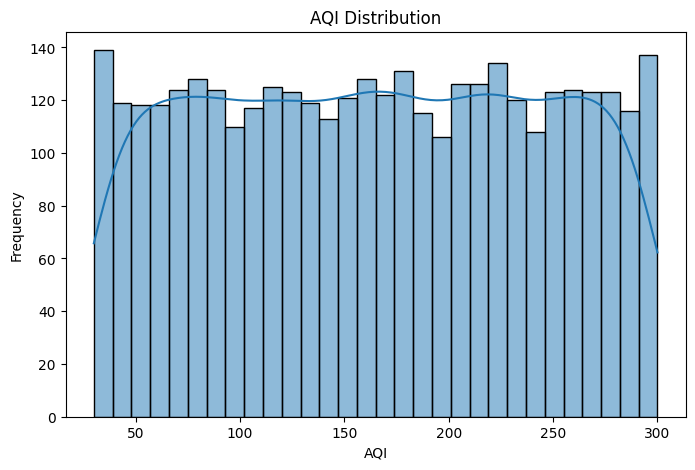

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["AQI"],
    bins=30,
    kde=True
)

plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()


In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")
display(correlation_matrix)


Correlation Matrix:


,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
AQI,1.000000,0.002061,0.030607,-0.005024,-0.024541,-0.005181,-0.014655,-0.017028,0.002174,-0.004216
PM2.5 (µg/m³),0.002061,1.000000,0.028090,0.003931,-0.018381,-0.027687,0.020701,0.008993,-0.007076,0.013813
PM10 (µg/m³),0.030607,0.028090,1.000000,-0.004077,0.012759,0.007613,-0.019438,-0.017691,-0.020588,-0.013834
NO2 (ppb),-0.005024,0.003931,-0.004077,1.000000,-0.013519,0.021388,-0.005020,0.008031,0.010663,0.031069
SO2 (ppb),-0.024541,-0.018381,0.012759,-0.013519,1.000000,0.014919,0.000005,0.021662,0.019030,0.018008
CO (ppm),-0.005181,-0.027687,0.007613,0.021388,0.014919,1.000000,-0.013504,-0.003512,0.019406,0.039103
O3 (ppb),-0.014655,0.020701,-0.019438,-0.005020,0.000005,-0.013504,1.000000,0.008053,0.014554,-0.000593
Temperature (°C),-0.017028,0.008993,-0.017691,0.008031,0.021662,-0.003512,0.008053,1.000000,-0.027397,0.006746
Humidity (%),0.002174,-0.007076,-0.020588,0.010663,0.019030,0.019406,0.014554,-0.027397,1.000000,0.017248
Wind Speed (m/s),-0.004216,0.013813,-0.013834,0.031069,0.018008,0.039103,-0.000593,0.006746,0.017248,1.000000


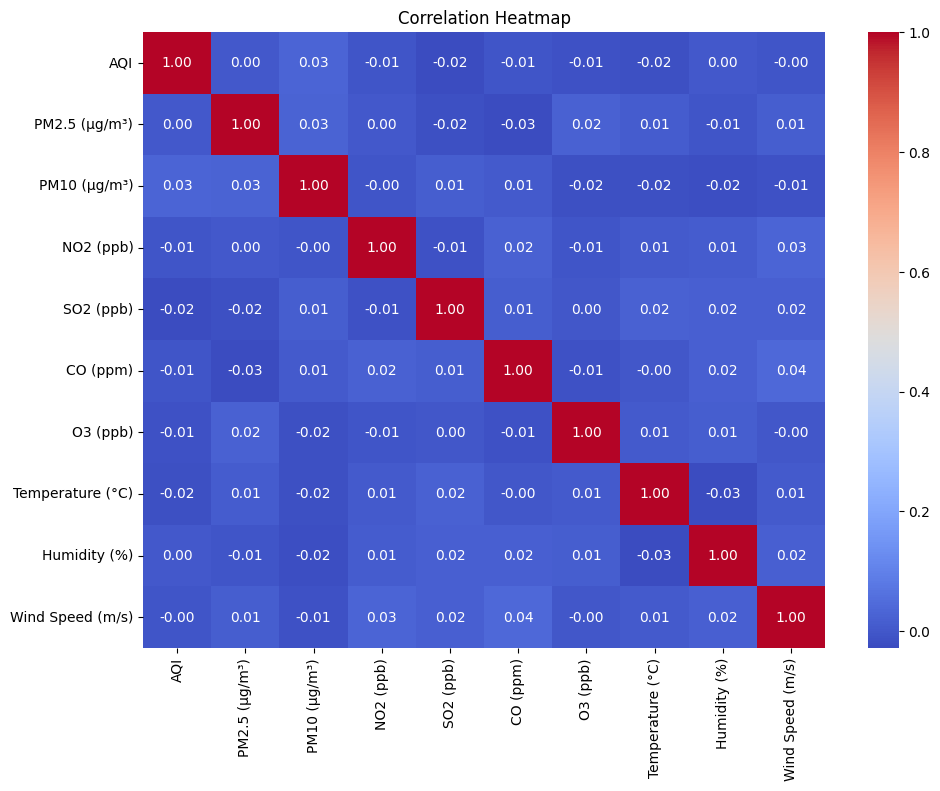

In [ ]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
aqi_correlation = correlation_matrix["AQI"].sort_values(
    ascending=False
)

print("\nCorrelation of Numerical Features with AQI:")
display(aqi_correlation)


Correlation of Numerical Features with AQI:


,AQI
AQI,1.000000
PM10 (µg/m³),0.030607
Humidity (%),0.002174
PM2.5 (µg/m³),0.002061
Wind Speed (m/s),-0.004216
NO2 (ppb),-0.005024
CO (ppm),-0.005181
O3 (ppb),-0.014655
Temperature (°C),-0.017028
SO2 (ppb),-0.024541


In [ ]:
target_column = "AQI"

# Automatically select numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# Remove AQI from predictors
feature_columns = [
    column for column in numeric_columns
    if column != target_column
]

X = df[feature_columns]
y = df[target_column]

print("Features used:")
print(feature_columns)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features used:
['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']

X shape: (3660, 9)
y shape: (3660,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


Training samples: 2928
Testing samples : 732


In [ ]:
ridge_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

print("\nRidge Regression trained successfully!")


Ridge Regression trained successfully!


In [ ]:
lasso_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Lasso(
        alpha=0.1,
        max_iter=10000
    ))
])

lasso_model.fit(X_train, y_train)

lasso_predictions = lasso_model.predict(X_test)

print("Lasso Regression trained successfully!")

Lasso Regression trained successfully!


In [ ]:
def evaluate_model(model_name, y_actual, y_predicted):

    mae = mean_absolute_error(
        y_actual,
        y_predicted
    )

    mse = mean_squared_error(
        y_actual,
        y_predicted
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_actual,
        y_predicted
    )

    return [
        model_name,
        mae,
        mse,
        rmse,
        r2
    ]

In [ ]:
ridge_result = evaluate_model(
    "Ridge Regression",
    y_test,
    ridge_predictions
)

lasso_result = evaluate_model(
    "Lasso Regression",
    y_test,
    lasso_predictions
)

In [ ]:
results = pd.DataFrame(
    [
        ridge_result,
        lasso_result
    ],
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2"
    ]
)

print("\n========== MODEL EVALUATION ==========")

display(
    results.style.format({
        "MAE": "{:.4f}",
        "MSE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)


========== MODEL EVALUATION ==========


,Model,MAE,MSE,RMSE,R2
0,Ridge Regression,69.6459,6346.9878,79.6680,-0.0001
1,Lasso Regression,69.6351,6344.9692,79.6553,0.0002


In [ ]:
print("\nRidge Regression:")
print("MAE :", ridge_result[1])
print("MSE :", ridge_result[2])
print("RMSE:", ridge_result[3])
print("R²  :", ridge_result[4])

print("\nLasso Regression:")
print("MAE :", lasso_result[1])
print("MSE :", lasso_result[2])
print("RMSE:", lasso_result[3])
print("R²  :", lasso_result[4])


Ridge Regression:
MAE : 69.64593502272452
MSE : 6346.987847999211
RMSE: 79.66798508810933
R²  : -9.500966309428094e-05

Lasso Regression:
MAE : 69.63513254862468
MSE : 6344.969206535459
RMSE: 79.65531499238114
R²  : 0.00022306771511182433


In [ ]:
comparison = pd.DataFrame({
    "Actual AQI": y_test.values,
    "Ridge Predicted AQI": ridge_predictions,
    "Lasso Predicted AQI": lasso_predictions
})

print("\nActual vs Predicted AQI:")
display(comparison.head(15))


Actual vs Predicted AQI:


,Actual AQI,Ridge Predicted AQI,Lasso Predicted AQI
0,212,163.924783,164.063949
1,106,158.561766,159.070403
2,245,168.646358,168.680300
3,55,161.624612,161.619760
4,95,162.858633,162.909571
5,196,167.623073,167.384617
6,294,166.501593,166.514703
7,263,160.395701,160.769783
8,238,166.150067,166.101380
9,207,167.497982,167.388191


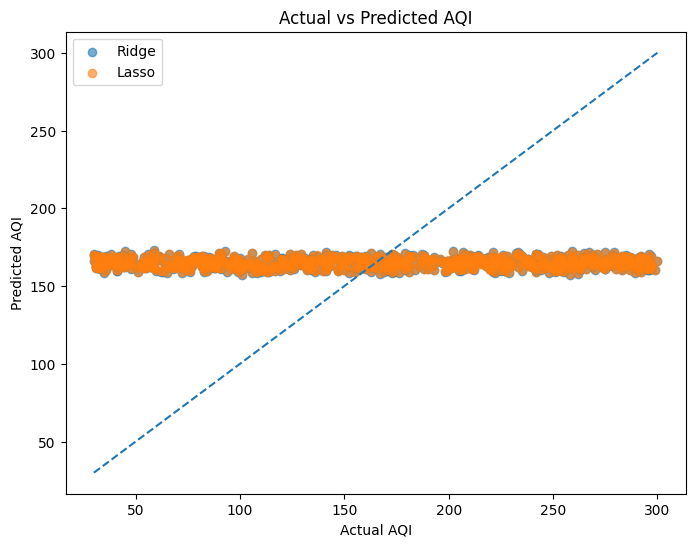

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    ridge_predictions,
    alpha=0.6,
    label="Ridge"
)

plt.scatter(
    y_test,
    lasso_predictions,
    alpha=0.6,
    label="Lasso"
)

# Ideal prediction line
min_value = min(y_test.min(), ridge_predictions.min(), lasso_predictions.min())
max_value = max(y_test.max(), ridge_predictions.max(), lasso_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.legend()
plt.show()


In [ ]:
print("\n==========================================")
print("          PROJECT EXECUTION SUMMARY")
print("==========================================")

print("Dataset Shape :", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicates    :", df.duplicated().sum())
print("Target        : AQI")
print("Models        : Ridge Regression, Lasso Regression")

print("\nRidge R² :", round(ridge_result[4], 4))
print("Lasso R² :", round(lasso_result[4], 4))

print("\nComplete EDA + ML implementation finished!")


          PROJECT EXECUTION SUMMARY
Dataset Shape : (3660, 13)
Missing Values: 0
Duplicates    : 0
Target        : AQI
Models        : Ridge Regression, Lasso Regression

Ridge R² : -0.0001
Lasso R² : 0.0002

Complete EDA + ML implementation finished!
